<a href="https://colab.research.google.com/github/mtchlorence/Projects/blob/main/DelaPizaKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler #StandardScaler

%matplotlib inline

In [ ]:
#Step 2: Load the dataset
data =pd.read_excel('/content/drive/MyDrive/Colab Notebooks/MACHINE-LEARNING-KNN.xlsx')
data.head(10)

,Age,Income
0,36,156000
1,41,82000
2,39,80000
3,39,155000
4,43,64000
5,28,51000
6,27,48000
7,41,63000
8,28,60000
9,29,61000


Text(0.5, 1.0, 'Age vs. Income Data')

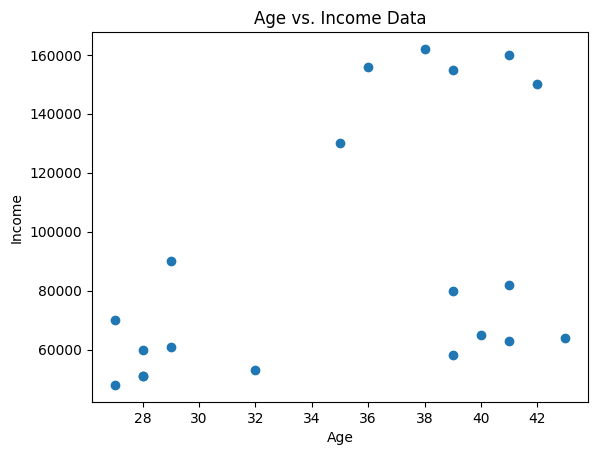

In [ ]:
#Step 3: Data Exploration
#Drop values that are nan
#data.dropna(inplace=True)
#data.drop('Name', axis='columns', inplace=True)

#To find the spread of the data. The method provides different measures of central tendency and location/ position.
#Note that there are values that can not be 0's.
#So, it is necessary to impute mean values to these respective columns/series.
data.describe()

plt.scatter(data['Age'],data['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs. Income Data')

In [ ]:
#Step 4: Apply the K Means Clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(data[['Age','Income']])
data['cluster']=kmeans.labels_
data.head()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,Age,Income,cluster
0,36,156000,2
1,41,82000,0
2,39,80000,0
3,39,155000,2
4,43,64000,1


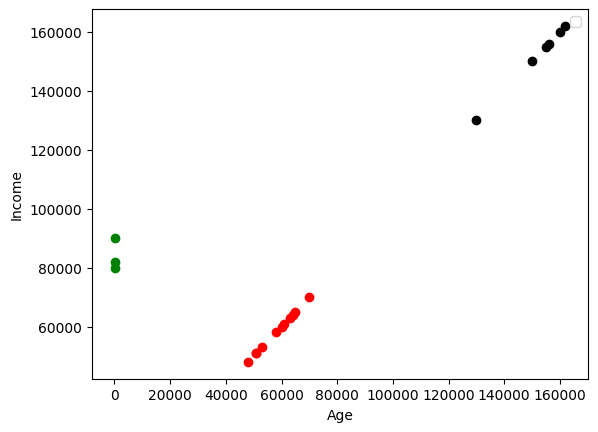

In [ ]:
data1 = data[data.cluster==0]
data2 = data[data.cluster==1]
data3 = data[data.cluster==2]
plt.scatter(data1['Age'],data1['Income'],color='green')
plt.scatter(data2.Income,data2['Income'],color='red')
plt.scatter(data3.Income,data3['Income'],color='black')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

In [ ]:
#Step 5: Transform the data
scaler =MinMaxScaler()
data[['Hours','Scores']]=scaler.fit_transform(data[['Age','Income']])

In [ ]:
#Use the same previous code or this alternatiuve code
kmeans = KMeans(n_clusters=3)
y_predicted = kmeans.fit_predict(data[['Age','Income']])
data['cluster']=y_predicted #pd.DataFrame(y_predicted, columns='cluster')
data

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,Age,Income,cluster,Hours,Scores
0,36,156000,1,0.5625,0.947368
1,41,82000,2,0.8750,0.298246
2,39,80000,2,0.7500,0.280702
3,39,155000,1,0.7500,0.938596
4,43,64000,0,1.0000,0.140351
5,28,51000,0,0.0625,0.026316
6,27,48000,0,0.0000,0.000000
7,41,63000,0,0.8750,0.131579
8,28,60000,0,0.0625,0.105263
9,29,61000,0,0.1250,0.114035


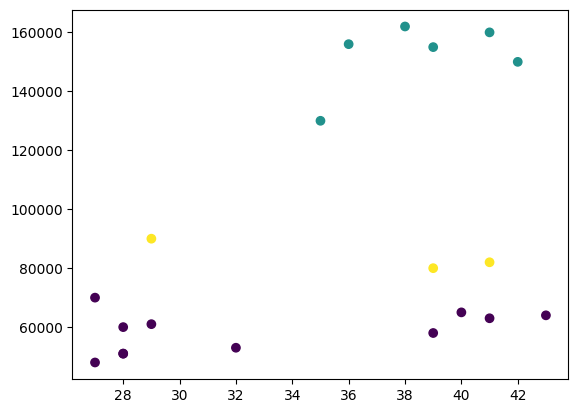

In [ ]:
#Show the scattergram with the scaled values
plt.scatter(x=data['Age'],y=data['Income'], c=data['cluster'])
#plt.xlim(-0.09,1.3)
#plt.ylim(-0.009,1.3)
plt.show()

In [ ]:
#The centroids
kmeans.cluster_centers_

array([[3.29090909e+01, 5.85454545e+04],
       [3.85000000e+01, 1.52166667e+05],
       [3.63333333e+01, 8.40000000e+04]])

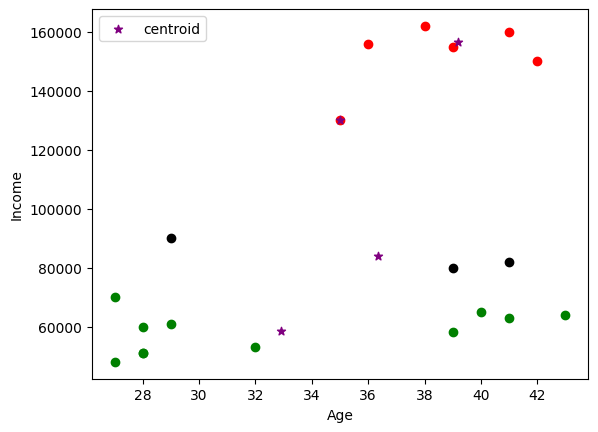

In [ ]:
#Step 6: Plot the results along with the centroids
data1=data[data.cluster==0]
data2=data[data.cluster==1]
data3=data[data.cluster==2]

plt.scatter(data1['Age'], data1 ['Income'],color='green')
plt.scatter(data2.Age,data2['Income'], color='red')
plt.scatter(data3.Age,data3['Income'],color='black')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],color='purple',marker='*',label='centroid')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

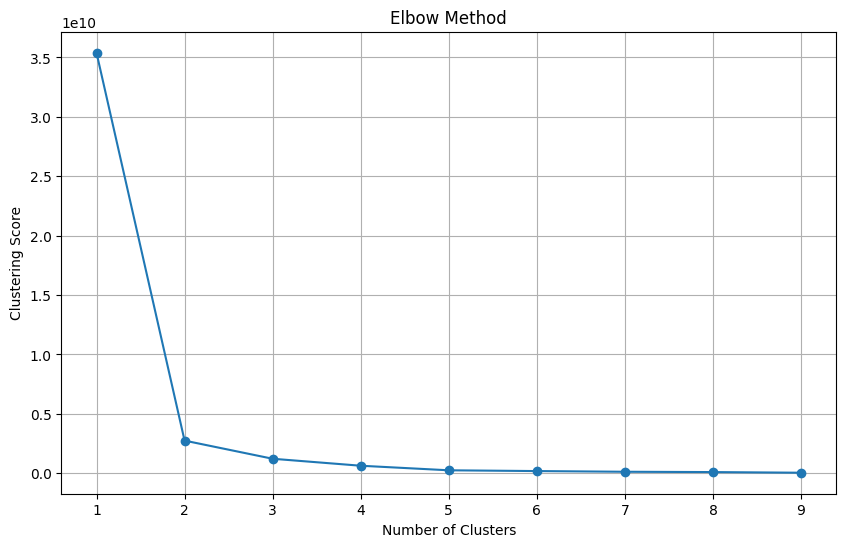

In [ ]:
#Step 7: Clustering the data (2 variables)
individual_clustering_score = []
for i in range(1,10):
  kmeans = KMeans(n_clusters = i, init = 'random', random_state = 42)
  kmeans.fit(data)
  individual_clustering_score.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1, 10), individual_clustering_score,'o-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Clustering Score')
plt.grid(True)
plt.show()

In [ ]:
#Create a function to work out optimum number of clusters
def optimise_k_means(data, max_k):
  means=[]
  inertias=[]
  for k in range (1, max_k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data) #['Hours', 'Scores'])

    means.append(k)
    inertias.append(kmeans.inertia_)

  #Generate the elbow plot
  #fid= plt.subplots(figsize=(10,5))
  plt.plot(means,inertias,'.-')
  plt.xlabel('Number of clusters')
  plt.ylabel('Inertia')
  plt.grid(True)
  plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

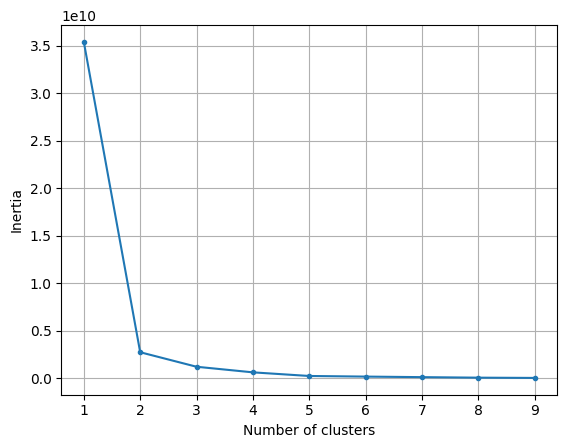

In [ ]:
optimise_k_means(data,10)

In [ ]:
#Step 8: Creating Multiple Cluster
for k in range(1,5):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(data[['Age','Income']])
  data[f'Cluster_{k}'] =kmeans.labels_

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


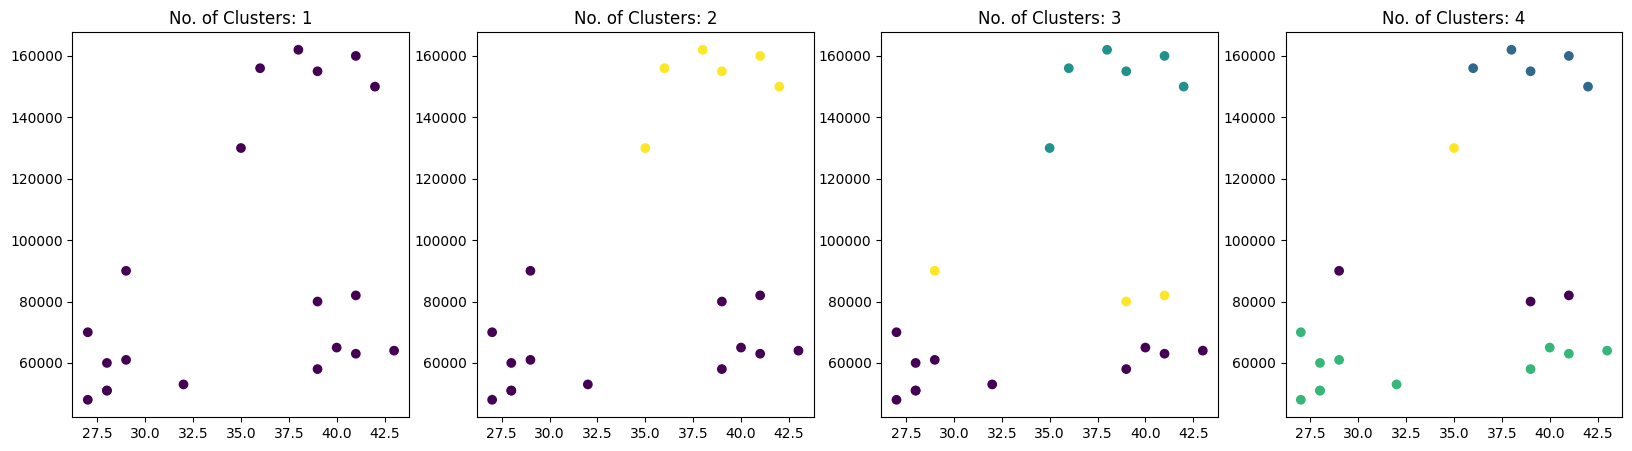

In [ ]:
fig,axs=plt.subplots(nrows=1,ncols=4, figsize=(20,5))
for i, ax in enumerate(fig.axes,start=1):
  ax.scatter(x=data['Age'], y=data['Income'],c=data[f'Cluster_{i}'])
  ax.set_title(f'No. of Clusters: {i}')